# 1.5.10 Feature Matching + Homography to find Objects

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [2]:
MIN_MATCH_COUNT = 10
img1 = cv2.imread('book2.jpg',0) # queryImage
img2 = cv2.imread('books.jpg',0) # trainImage

In [3]:
# Initiate SIFT detector
sift = cv2.SIFT_create()
# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2,None)

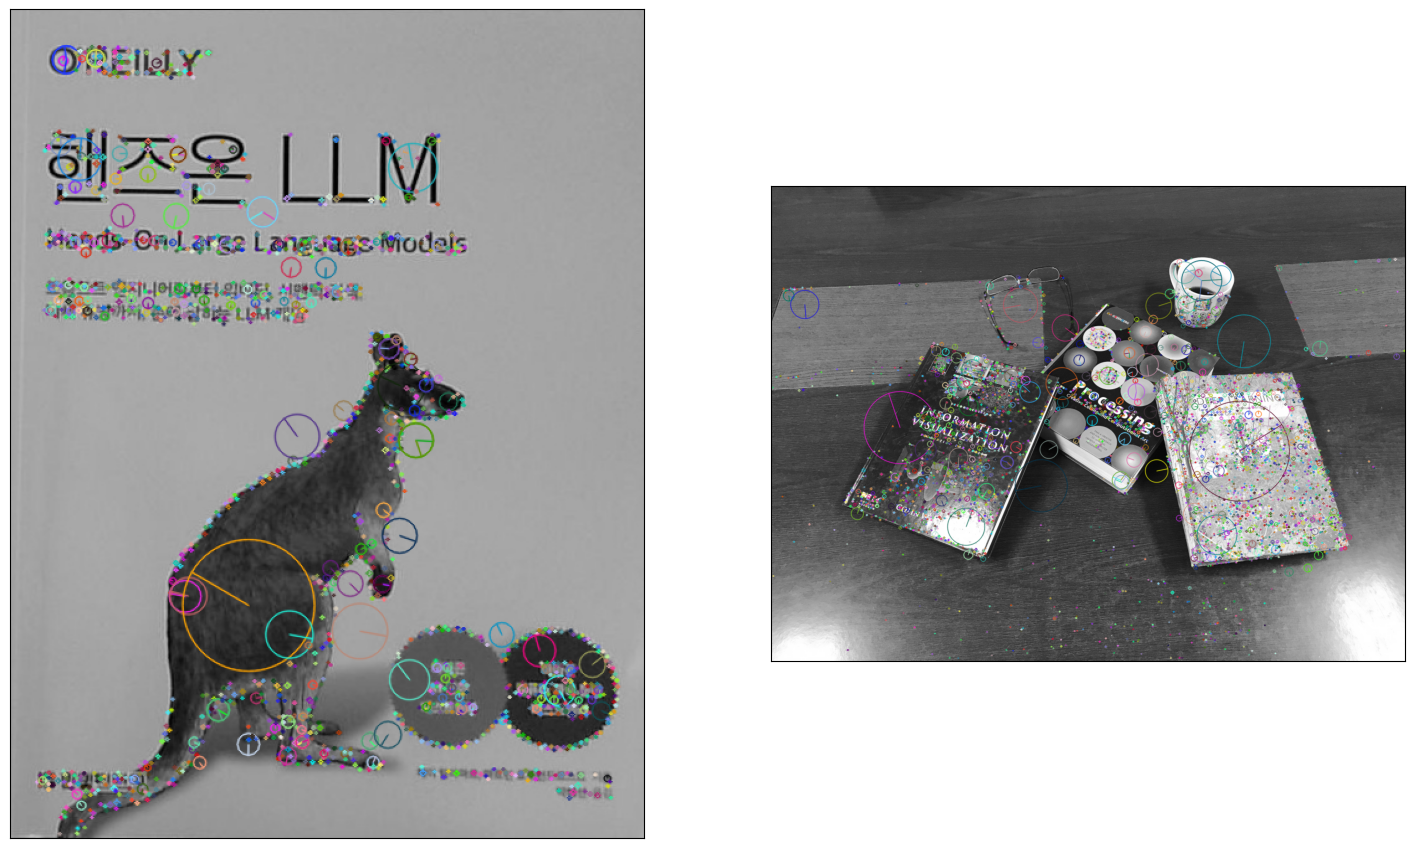

In [4]:
img1v = cv2.drawKeypoints(img1, kp1, img1, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS) #,flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
img2v = cv2.drawKeypoints(img2, kp2, img2, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize = (18,18))
plt.subplot(1,2,1), plt.imshow(img1v), plt.xticks([]), plt.yticks([])
plt.subplot(1,2,2), plt.imshow(img2v), plt.xticks([]), plt.yticks([])
plt.show()

In [5]:
FLANN_INDEX_KDTREE = 0
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks = 50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1,des2,k=2)

In [6]:
# store all the good matches as per Lowe's ratio test.
good = []
for m,n in matches:
    if m.distance < 2*n.distance:
        good.append(m)

In [7]:
print(len(good))

1893


In [8]:
if len(good)>MIN_MATCH_COUNT:
    src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
    dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC,5.0)
    matchesMask = mask.ravel().tolist()
    h,w = img1.shape
    pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
    dst = cv2.perspectiveTransform(pts,M)
    img2 = cv2.polylines(img2,[np.int32(dst)],True,255,3, cv2.LINE_AA)
else:
    print("Not enough matches are found - %d/%d" % (len(good),MIN_MATCH_COUNT))
    matchesMask = None

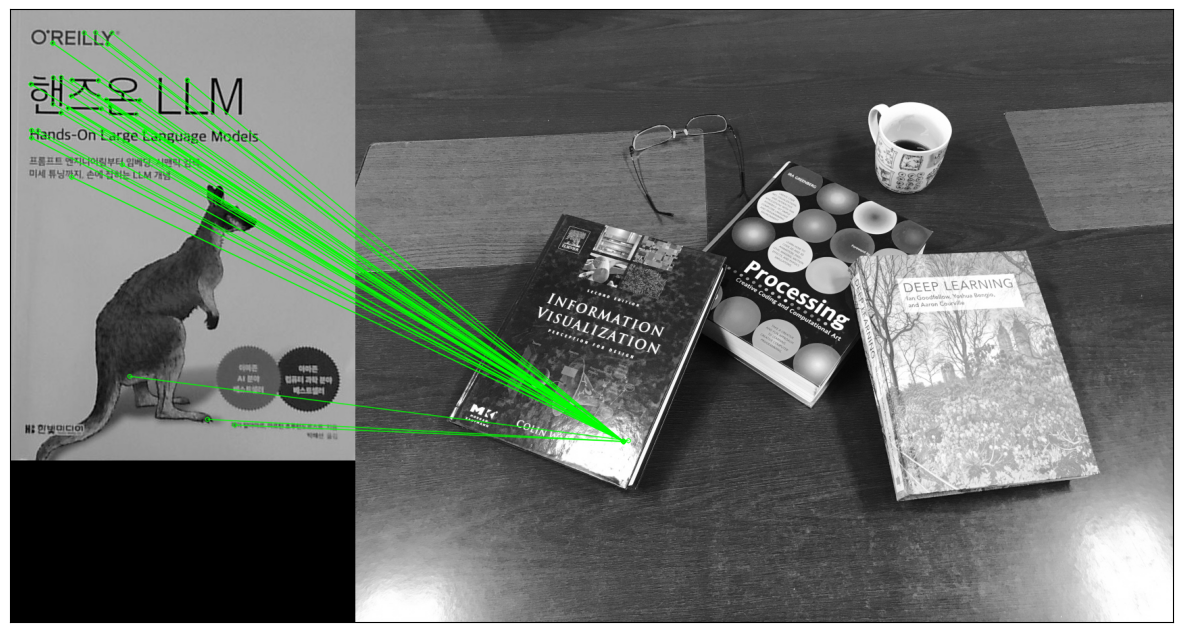

(<matplotlib.image.AxesImage at 0x18db065f910>, ([], []), ([], []), None)

In [9]:
draw_params = dict(matchColor = (0,255,0), singlePointColor = None, matchesMask = matchesMask, flags = 2)
img3 = cv2.drawMatches(img1,kp1,img2,kp2,good,None,**draw_params)
plt.figure(figsize = (15,15))
plt.imshow(img3, 'gray'), plt.xticks([]), plt.yticks([]), plt.show()

In [ ]:
cap = cv2.VideoCapture(0)
while(cap.isOpened()):
    ret, frame = cap.read()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    kp2, des2 = sift.detectAndCompute(gray,None)
    img2v = cv2.drawKeypoints(frame, kp2, frame, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    if len(kp2) > 10 :
        matches = flann.knnMatch(des1,des2,k=2)
        good = []
        for m,n in matches:
            if m.distance < 0.75*n.distance:
                good.append(m)
        print(len(good))
        if len(good)>MIN_MATCH_COUNT:
            src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
            dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
            M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC,5.0)
            matchesMask = mask.ravel().tolist()
            h,w = img1.shape
            pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
            dst = cv2.perspectiveTransform(pts,M)
            img2 = cv2.polylines(img2,[np.int32(dst)],True,255,3, cv2.LINE_AA)
        else:
            print("Not enough matches are found - %d/%d" % (len(good),MIN_MATCH_COUNT))
            matchesMask = None

        draw_params = dict(matchColor = (0,255,0), singlePointColor = None, matchesMask = matchesMask, flags = 2)
        img3 = cv2.drawMatches(img1,kp1,frame,kp2,good,None,**draw_params)
        cv2.imshow('frame',img3)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

33
29
26
29
22
26
51
37
95
25
92
23
60
57
65
40
92
39
45
42
27
72
72
87
58
91
97
111
105
201
226
121
78
250
218
213
302
191
172
224
316
303
276
308
335
238
243
226
172
187
270
324
282
332
306
283
201
276
243
267
256
286
241
209
243
239
281
248
297
207
236
213
230
218
198
219
227
207
220
223
212
264
224
208
231
195
204
168
158
184
178
171
241
174
193
159
155
166
138
155
129
141
111
130
105
119
122
97
82
81
75
62
76
61
53
57
46
67
75
44
116
163
126
140
219
229
228
226
225
210
198
175
280
232
253
281
277
299
154
249
247
122
283
195
110
95
72
109
127
110
107
94
94
77
96
91
43
37
45
63
56
39
73
70
43
143
46
90
221
136
29
43
136
48
54
68
196
134
105
82
124
151
134
107
88
144
155
119
100
147
136
91
103
126
138
125
96
89
122
68
105
88
122
86
87
206
115
343
238
107
91
160
221
235
137
249
221
290
142
158
191
194
184
192
213
121
31
18
80
48
73
23
31
24
125
89
35
48
60
70
111
46
65
71
145
137
250
354
224
270
258
296
279
293
267
276
224
280
304
275
235
268
287
255
254
198
192
191
165
153
109
218
26

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\matmul.dispatch.cpp:550: error: (-215:Assertion failed) scn + 1 == m.cols in function 'cv::perspectiveTransform'


: 